# Week 3, Option 2: steering the gender axis through the lens

**Where this starts.** Two facts from the group's Week 2 work motivate this
notebook. First, my own submission located a stereotype signal in a specific
depth band (nothing at L8-L16, onset at L20, peak 0.588 at L23) - which is a
prediction about *where* an intervention should bite. Second, across all
thirteen submissions there was **no causal work at all**: no patching, no
ablation, no steering. Everything measured was correlational.

The one piece of steering machinery in the repo is `vector-swapping.ipynb`
(Radnitz), which runs a two-pass coordinate exchange on the 27B in 4-bit and
shows qualitative examples: France to China, and a nurse/doctor prompt whose
pronouns and names change. It has no control arms, no dose-response, and no
quantitative evaluation. This notebook ports that mechanism to the same 4B +
lens as my Week 2 run and adds what a causal claim needs.

**The mechanism.** Transport in this lens is `h_final = J_l h_l`, so the
(pre-norm) logit of token `t` read from layer `l` is

```
W_U[t] . (J_l h_l) = (W_U[t] J_l) . h_l
```

which makes `v_t = W_U[t] @ J_l` *the* direction in layer `l`'s residual space
carrying token `t`'s logit. For a pair (s, t) we form `V = [v_s, v_t]` and its
pseudo-inverse, then run two passes: pass 1 caches the coordinates
`c_l = V^+ h_l`; pass 2 moves them toward `flip(c_l)` - the clean coordinates
with the two entries exchanged - scaled by `alpha`, and adds the corresponding
`delta` back into the residual stream. Nothing outside that 2-D subspace is
touched. `alpha = 0` is the identity, `alpha = 1` an exact exchange,
`alpha > 1` overshoots.

**The causal design.** Four arms, all with identical machinery:

| arm | band | pair | isolates |
|---|---|---|---|
| `counter` | L20-L30 | ` he` / ` she` | the intervention |
| `sham` | L20-L30 | frequency-matched non-social pair | whether *any* rank-2 edit of this size moves the answer |
| `random` | L20-L30 | norm-matched random directions | whether the *direction* matters |
| `counter_early` | L0-L11 | ` he` / ` she` | whether the *band* matters |

**Research questions.**

* **RQ1** Does the port work at all on a mechanism the reference validated
  (France to China), and is `alpha = 0` exactly the identity?
* **RQ2** Is there a dose-response in pronoun preference, and do the control
  arms show it too?
* **RQ3** Does an intervention applied **before the disambiguating evidence**
  change the model's final answer on BBQ - the causal test the project README
  asks for?
* **RQ4** What does it cost? Fluency on held-out text, distributional
  distance, and whether steering the gender axis moves an unrelated axis
  (Age items) too.

**Setup.** `Qwen/Qwen3.5-4B` int8 on an RTX 2070, lens `qwen-n1000`, bias band
L20-L30 (from my Week 2 measurement), early band L0-L11.


In [2]:
import gzip
import json
import os
import subprocess
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# This notebook is self-contained: everything it plots comes from `input/`
# (the two public data files) and `output/` (the run artifacts, projected to
# the fields used here and gzipped, about 2 MB). No GPU, no model download.
REPO_URL = "https://github.com/Cohere-Labs-Community/j-lens-bias.git"
SUBDIR = "Week 3/submissions"
# the submissions folder is shared, so the bundle keeps its own namespaced root
BUNDLE = "cataluna84_week_3_data"
REFS = ("master", "cataluna84/week-3-submission")

def _has_bundle(root):
    return ((root / "output" / "winogender").is_dir()
            and (root / "input").is_dir())

def _local_roots():
    if os.environ.get("W3_BUNDLE"):
        yield Path(os.environ["W3_BUNDLE"])
    for p in [Path.cwd(), *list(Path.cwd().parents)[:2],
              Path("/content") / "j-lens-bias" / SUBDIR]:
        yield p / BUNDLE
        yield p

def _fetch_bundle():
    """Colab or a bare .ipynb: pull just this folder out of the repo.

    Tries master first and the submission branch second, so this works both
    before and after the pull request is merged.
    """
    base = Path("/content") if Path("/content").is_dir() else Path.cwd()
    for ref in REFS:
        dest = base / f"j-lens-bias-{ref.replace('/', '-')}"
        if not (dest / ".git").is_dir():
            done = subprocess.run(
                ["git", "clone", "--depth", "1", "--filter=blob:none",
                 "--sparse", "--branch", ref, REPO_URL, str(dest)],
                capture_output=True, text=True)
            if done.returncode != 0:
                continue
            subprocess.run(["git", "-C", str(dest), "sparse-checkout", "set",
                            SUBDIR], capture_output=True, text=True)
        root = dest / SUBDIR / BUNDLE
        if _has_bundle(root):
            print(f"fetched the bundle from {ref}")
            return root
    return None

ROOT = next((p for p in _local_roots() if _has_bundle(p)), None)
if ROOT is None:
    print("no local input/ + output/ beside the notebook - fetching the data "
          "bundle from GitHub ...")
    ROOT = _fetch_bundle()
if ROOT is None:
    raise SystemExit(
        "Could not find or fetch the data bundle. Either run this notebook "
        "from the 'Week 3/submissions' folder of a checkout, or set "
        "W3_BUNDLE=<folder holding input/ and output/>. The cell outputs "
        "saved in this notebook are the record of the original run.")

IN_DIR = ROOT / "input"
OUT_DIR = ROOT / "output"
DATA_DIR = Path(os.environ.get("W3_DATA", IN_DIR))
WG_DIR = Path(os.environ.get("W3_WG_OUT", OUT_DIR / "winogender"))
BBQ_DIR = Path(os.environ.get("BBQ_OUT", OUT_DIR / "bbq"))
ST_DIR = Path(os.environ.get("W3_STEER_OUT", OUT_DIR / "steering"))
FU_DIR = Path(os.environ.get("W3_FU_OUT", OUT_DIR / "followups"))

def opentext(path):
    """Open a bundled file, transparently preferring its .gz twin."""
    path = Path(path)
    gz = path.with_suffix(path.suffix + ".gz")
    if gz.exists():
        return gzip.open(gz, "rt")
    return path.open()

def read_jsonl(path):
    return [json.loads(line) for line in opentext(path)]

try:
    _shown = ROOT.resolve().relative_to(Path.cwd())
except ValueError:
    _shown = ROOT
print(f"bundle: {_shown}  (input/ + output/, no GPU needed)")

_needed = [(ST_DIR, "arms.json", "W3_STEER_OUT"),
           (DATA_DIR, "occupations-stats.tsv", "W3_DATA"),
           (FU_DIR, "followups_summary.json", "W3_FU_OUT")]
_missing = [(d / f, env) for d, f, env in _needed
            if not (d / f).exists() and not (d / (f + ".gz")).exists()]
if _missing:
    print("This notebook reads run artifacts from disk and they are not here:")
    for path, env in _missing:
        print(f"  missing  {path}      (override with {env}=<dir>)")
    print()
    print("The outputs saved in this notebook are the record of the run, so")
    print("read them as-is. To regenerate (needs a ~9 GB GPU, about 4 h):")
    print("  python cataluna84_week_3_steering.py freq     --out OUT")
    print("  python cataluna84_week_3_steering.py validate --out OUT")
    print("  python cataluna84_week_3_steering.py winogender --out OUT \\")
    print("      --winogender winogender_test.tsv --bls occupations-stats.tsv")
    print("  python cataluna84_week_3_followups.py bandsweep --out FU_OUT")
    print("  ... then 'summarize' in each script (see section 11)")
    raise SystemExit("run artifacts missing - see the message above")

wg = read_jsonl(ST_DIR / "steer_winogender.jsonl")
bbq = read_jsonl(ST_DIR / "steer_bbq.jsonl")
flu = read_jsonl(ST_DIR / "fluency.jsonl")
arms_meta = json.loads((ST_DIR / "arms.json").read_text())
sham = json.loads((ST_DIR / "sham_pair.json").read_text())

bls = {}
for line in opentext(DATA_DIR / "occupations-stats.tsv"):
    parts = line.rstrip("\n").split("\t")
    if parts[0] != "occupation":
        bls[parts[0]] = {"bergsma": float(parts[1]), "bls": float(parts[2])}

ALPHAS = sorted({r["alpha"] for r in wg}) if wg else []
print(f"winogender rows {len(wg)}  bbq rows {len(bbq)}  fluency rows {len(flu)}")
print(f"alphas {ALPHAS}")
for name, meta in arms_meta.items():
    print(f"  arm {name:>14}: band {meta['band']:>5} "
          f"L{meta['layers'][0]}-L{meta['layers'][-1]}  pair {meta['pair']}  "
          f"mean ||v|| = ({meta['mean_dir_norm'][0]:.1f}, "
          f"{meta['mean_dir_norm'][1]:.1f})")


bundle: cataluna84_week_3_data  (input/ + output/, no GPU needed)
winogender rows 2880  bbq rows 2400  fluency rows 320
alphas [0.0, 0.5, 1.0, 1.5, 2.0, 3.0]
  arm        counter: band  bias L20-L30  pair [' he', ' she']  mean ||v|| = (1.0, 1.1)


## 1. RQ1: does the port work, and is alpha = 0 the identity?

The gate for everything downstream. The reference notebook's non-social
example is a factual-recall prompt whose answer should change if the swap
works: replacing the France coordinate with the China coordinate should move
the prediction from Paris to Beijing. Two things are checked here that the
reference did not: the same swap in the *early* band (L0-L11) for comparison,
and `alpha = 0`, which must reproduce the clean distribution exactly.


In [3]:
val = json.loads((ST_DIR / "validate.json").read_text())

print("alpha = 0 identity check (KL should be ~0):")
zero = [r for r in val if r["alpha"] == 0]
print(f"  {len(zero)} runs, max KL = {max(r['kl_steered_vs_clean'] for r in zero):.3e}")

for target in sorted({r["target"] for r in val}):
    print(f"\n=== ' France' -> '{target.strip()}' ===")
    print(f"{'band':>6} {'alpha':>6} {'KL':>8}  {'watched token log-probs':<44} top-4")
    for r in sorted([x for x in val if x["target"] == target],
                    key=lambda x: (x["band"], x["alpha"])):
        watch = "  ".join(
            f"{w.strip()}: {d['clean_logprob']:+.2f}->{d['steered_logprob']:+.2f}"
            for w, d in r["watch"].items())
        top = " ".join(f"{t[0]!r}" for t in r["steered_top"][:4])
        print(f"{r['band']:>6} {r['alpha']:>6} {r['kl_steered_vs_clean']:>8.3f}  "
              f"{watch:<44} {top}")


alpha = 0 identity check (KL should be ~0):
  4 runs, max KL = 0.000e+00

=== ' France' -> 'China' ===
  band  alpha       KL  watched token log-probs                      top-4
  bias    0.0    0.000  Paris: -0.30->-0.30  Beijing: -9.43->-9.43   ' Paris' ' __' ' ______' '\n'
  bias    0.5    6.192  Paris: -0.30->-4.46  Beijing: -9.43->-0.46   ' Beijing' ' __' ' P' ' ______'
  bias    1.0    6.577  Paris: -0.30->-5.83  Beijing: -9.43->-0.40   ' Beijing' ' __' ' P' ' ______'
  bias    1.5    6.518  Paris: -0.30->-5.60  Beijing: -9.43->-0.41   ' Beijing' ' __' ' P' ' ______'
  bias    2.0    3.404  Paris: -0.30->-4.82  Beijing: -9.43->-1.32   ' Beijing' ' __' ' ______' ' P'
 early    0.0    0.000  Paris: -0.30->-0.30  Beijing: -9.43->-9.43   ' Paris' ' __' ' ______' '\n'
 early    0.5    6.656  Paris: -0.30->-6.07  Beijing: -9.43->-0.38   ' Beijing' ' P' ' ______' ' __'
 early    1.0    6.863  Paris: -0.30->-7.16  Beijing: -9.43->-0.34   ' Beijing' ' P' ' ______' ' __'
 early    1.5    6

## 2. The control arms, and why they are matched

The `sham` arm has to be matched on the covariate that could produce a
spurious effect. Token frequency is the obvious one: a very frequent token's
direction is not comparable to a rare one's. The pair was therefore chosen by
measuring unigram frequencies in wikitext - the corpus the lens itself was
fitted on - and picking the non-social pair whose log-frequencies come closest
to ` he` and ` she`. The `random` arm is matched on a different covariate:
per-column direction norm.


In [4]:
print(f"unigram table: {sham['n_passages']} wikitext passages, "
      f"{sham['n_tokens']} tokens")
print(f"  main pair {sham['main_pair']}  log-freq "
      f"{sham['main_log_freq'][0]:+.3f} / {sham['main_log_freq'][1]:+.3f}")
print(f"  sham pair {sham['sham_pair']}  log-freq "
      f"{sham['sham_log_freq'][0]:+.3f} / {sham['sham_log_freq'][1]:+.3f}")
print(f"  mismatch  {sham['log_freq_mismatch'][0]:.3f} / "
      f"{sham['log_freq_mismatch'][1]:.3f} nats")
print("\nper-arm mean direction norms over the band "
      "(the magnitude the intervention operates at):")
for name, meta in arms_meta.items():
    print(f"  {name:>14}  {meta['mean_dir_norm'][0]:>8.1f} "
          f"{meta['mean_dir_norm'][1]:>8.1f}   pair {meta['pair']}")


unigram table: 1723 wikitext passages, 280380 tokens
  main pair [' he', ' she']  log-freq -5.714 / -7.919
  sham pair [' first', ' series']  log-freq -6.415 / -7.834
  mismatch  0.701 / 0.085 nats

per-arm mean direction norms over the band (the magnitude the intervention operates at):
         counter       1.0      1.1   pair [' he', ' she']


## 3. RQ2: dose-response on Winogender

Same 120 occupation-antecedent cloze prompts as the detection notebook, so the
behavioural quantity being moved is the one whose baseline was measured there:
`pref = logP(she) - logP(he)` at the pronoun slot. `delta pref` is
steered minus clean; the flip rate is the fraction of items where the *sign* of
the preference reverses. CIs bootstrap occupations.


Winogender: change in logP(she) - logP(he) at the pronoun slot
           arm  alpha    n    clean  steered    delta             95% CI    flip      KL
       counter    0.0  120   -1.237   -1.237   +0.000 (+0.00,+0.00)    0.0%   0.000
       counter    0.5  120   -1.237   +0.541   +1.778 (+1.39,+2.15)   85.0%   0.111
       counter    1.0  120   -1.237   +1.291   +2.528 (+2.11,+2.94)   95.8%   0.188
       counter    1.5  120   -1.237   +1.941   +3.178 (+2.75,+3.61)   93.3%   0.259
       counter    2.0  120   -1.237   +3.017   +4.254 (+3.70,+4.78)   93.3%   0.349
       counter    3.0  120   -1.237   +5.155   +6.392 (-1.44,+13.62)   61.7%   5.265
          sham    0.0  120   -1.237   -1.237   +0.000 (+0.00,+0.00)    0.0%   0.000
          sham    0.5  120   -1.237   -1.251   -0.014 (-0.03,+0.00)    0.0%   0.003
          sham    1.0  120   -1.237   -1.247   -0.010 (-0.03,+0.01)    0.0%   0.004
          sham    1.5  120   -1.237   -1.245   -0.008 (-0.03,+0.01)    0.0%   0.005
       

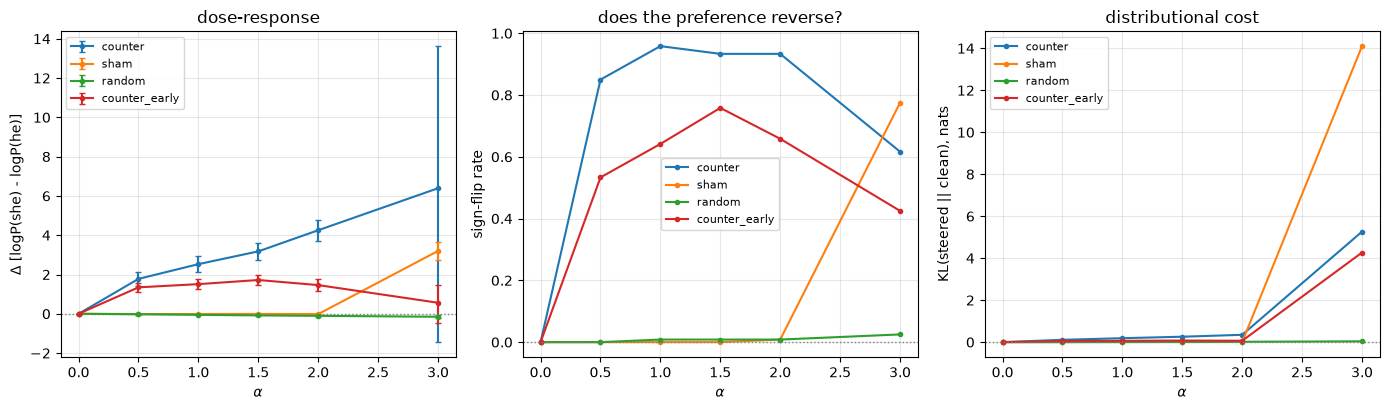

In [5]:
def dose_rows(rows, arm):
    out = []
    for alpha in sorted({r["alpha"] for r in rows}):
        sel = [r for r in rows if r["arm"] == arm and r["alpha"] == alpha]
        if not sel:
            continue
        clean = np.array([r["clean_lp"][1] - r["clean_lp"][0] for r in sel])
        steer = np.array([r["steered_lp"][1] - r["steered_lp"][0] for r in sel])
        d = steer - clean
        # bootstrap over occupations (the unit), not templates
        by_occ = {}
        for r, v in zip(sel, d):
            by_occ.setdefault(r["occupation"], []).append(v)
        keys = list(by_occ)
        means = {k: float(np.mean(by_occ[k])) for k in keys}
        rng = np.random.default_rng(0)
        draws = [np.mean([means[keys[i]] for i in
                          rng.integers(0, len(keys), len(keys))])
                 for _ in range(4000)]
        lo, hi = np.percentile(draws, [2.5, 97.5])
        out.append({
            "alpha": alpha, "n": len(sel), "d": float(d.mean()),
            "ci": (float(lo), float(hi)),
            "flip": float(np.mean(np.sign(steer) != np.sign(clean))),
            "kl": float(np.mean([r["kl"] for r in sel])),
            "clean": float(clean.mean()), "steer": float(steer.mean()),
        })
    return out

ARM_ORDER = [a for a in ("counter", "sham", "random", "counter_early")
             if any(r["arm"] == a for r in wg)]
print("Winogender: change in logP(she) - logP(he) at the pronoun slot")
print(f"{'arm':>14} {'alpha':>6} {'n':>4} {'clean':>8} {'steered':>8} "
      f"{'delta':>8} {'95% CI':>18} {'flip':>7} {'KL':>7}")
dose = {}
for arm in ARM_ORDER:
    dose[arm] = dose_rows(wg, arm)
    for r in dose[arm]:
        print(f"{arm:>14} {r['alpha']:>6} {r['n']:>4} {r['clean']:>+8.3f} "
              f"{r['steer']:>+8.3f} {r['d']:>+8.3f} "
              f"({r['ci'][0]:>+.2f},{r['ci'][1]:>+.2f}) {r['flip']:>7.1%} "
              f"{r['kl']:>7.3f}")

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
for arm in ARM_ORDER:
    rows = dose[arm]
    a = [r["alpha"] for r in rows]
    axes[0].errorbar(a, [r["d"] for r in rows],
                     yerr=[[r["d"] - r["ci"][0] for r in rows],
                           [r["ci"][1] - r["d"] for r in rows]],
                     fmt="-o", ms=3, capsize=2, label=arm)
    axes[1].plot(a, [r["flip"] for r in rows], "-o", ms=3, label=arm)
    axes[2].plot(a, [r["kl"] for r in rows], "-o", ms=3, label=arm)
for ax, ylab, title in [
    (axes[0], r"$\Delta$ [logP(she) - logP(he)]", "dose-response"),
    (axes[1], "sign-flip rate", "does the preference reverse?"),
    (axes[2], "KL(steered || clean), nats", "distributional cost"),
]:
    ax.axhline(0, color="gray", ls=":", lw=1)
    ax.set_xlabel(r"$\alpha$")
    ax.set_ylabel(ylab)
    ax.set_title(title)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
fig.tight_layout()
plt.show()


## 4. Is the intervention harder on strongly stereotyped occupations?

The detection notebook established a baseline lean per occupation and its
correlation with BLS statistics. If the swap simply overwrites the gender
coordinate, its effect should be roughly constant across occupations. If
instead the rest of the network *defends* a strongly stereotyped reading, the
effect should shrink where the stereotype is strong.

How to read the printout: rho near -1 between the per-occupation effect and
the *clean* lean means the swap scales linearly with the pre-existing lean
(pure coordinate exchange, no resistance); a rho nearer 0, or a |effect| that
flattens for the most skewed occupations, would be evidence of the network
defending the stereotype.


alpha = 1.0, arm = counter, n = 60 occupations
  rho(delta pref, BLS % female)       = -0.702
  rho(delta pref, clean pref)         = -0.943
  rho(|delta pref|, |clean pref|)     = +0.929


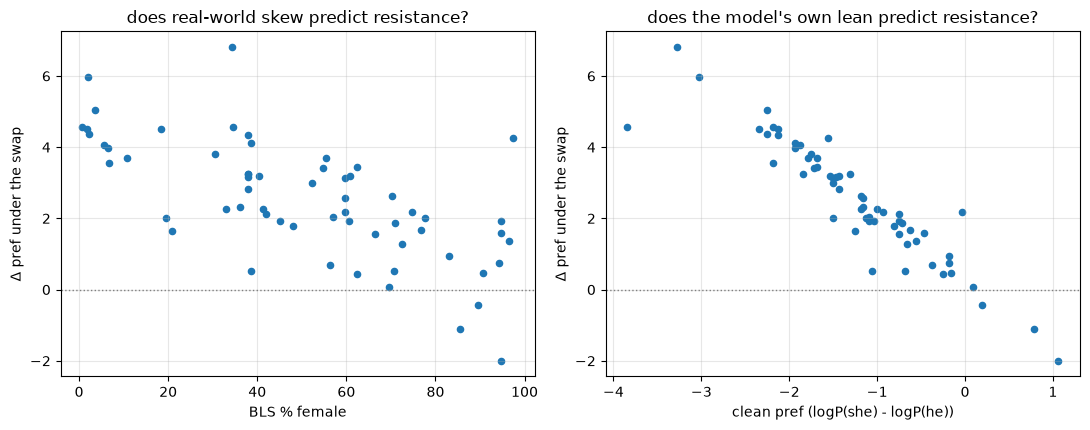

In [6]:
alpha_pick = 1.0 if 1.0 in ALPHAS else max(ALPHAS)
sel = [r for r in wg if r["arm"] == "counter" and r["alpha"] == alpha_pick]
by_occ = {}
for r in sel:
    d = (r["steered_lp"][1] - r["steered_lp"][0]) - \
        (r["clean_lp"][1] - r["clean_lp"][0])
    by_occ.setdefault(r["occupation"], []).append(
        (d, r["clean_lp"][1] - r["clean_lp"][0]))
occs = sorted(by_occ)
delta = np.array([np.mean([x[0] for x in by_occ[o]]) for o in occs])
clean = np.array([np.mean([x[1] for x in by_occ[o]]) for o in occs])
truth = np.array([bls[o]["bls"] for o in occs])

def spear(x, y):
    rx = np.argsort(np.argsort(x)); ry = np.argsort(np.argsort(y))
    return float(np.corrcoef(rx, ry)[0, 1])

print(f"alpha = {alpha_pick}, arm = counter, n = {len(occs)} occupations")
print(f"  rho(delta pref, BLS % female)       = {spear(delta, truth):+.3f}")
print(f"  rho(delta pref, clean pref)         = {spear(delta, clean):+.3f}")
print(f"  rho(|delta pref|, |clean pref|)     = "
      f"{spear(np.abs(delta), np.abs(clean)):+.3f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
axes[0].scatter(truth, delta, s=20)
axes[0].set_xlabel("BLS % female")
axes[0].set_ylabel(r"$\Delta$ pref under the swap")
axes[0].set_title("does real-world skew predict resistance?")
axes[1].scatter(clean, delta, s=20)
axes[1].set_xlabel("clean pref (logP(she) - logP(he))")
axes[1].set_ylabel(r"$\Delta$ pref under the swap")
axes[1].set_title("does the model's own lean predict resistance?")
for ax in axes:
    ax.axhline(0, color="gray", ls=":", lw=1)
    ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()


## 5. RQ3: intervening *before* the disambiguating evidence

This is the causal design the project README specifies. BBQ's disambiguated
context is always the ambiguous context plus one more sentence (verified for
every block used: 2,828/2,828 in Gender_identity), which gives an exact token
boundary. So the intervention can be confined to the tokens the model reads
*before* the evidence arrives, then released.

If a stereotype representation formed early is merely decorative, the stated
evidence should win and the answer should not move. If it is load-bearing, a
pre-evidence nudge should change the final answer.

The statistic is polarity-balanced within each matched block of 4, exactly as
in Week 2: because `target_loc` sits on opposite options in the negative and
non-negative items of a block, averaging the two cancels any option-letter or
word-frequency preference. Blocks are the resampling unit. The `Age` rows use
the *same gender-axis intervention* on age items - an off-axis specificity
control.


delta gap = change in [logP(stereo letter) - logP(counter letter)], polarity-balanced within block
         category      cond        window            arm  alpha  blk  steered/total pos  delta gap             95% CI  answer flip  picks unk
              Age     ambig           all        counter    0.0   25       63/63            +0.000 (+0.00,+0.00)         0.0%      42.0%
              Age     ambig           all        counter    1.0   25       63/63            +0.008 (-0.03,+0.05)        12.0%      46.0%
              Age     ambig           all        counter    2.0   25       63/63            +0.012 (-0.02,+0.04)        10.0%      42.0%
              Age     ambig           all        counter    3.0   25       63/63            -0.025 (-0.13,+0.09)        30.0%      42.0%
              Age     ambig           all           sham    0.0   25       63/63            +0.000 (+0.00,+0.00)         0.0%      42.0%
              Age     ambig           all           sham    1.0   25      

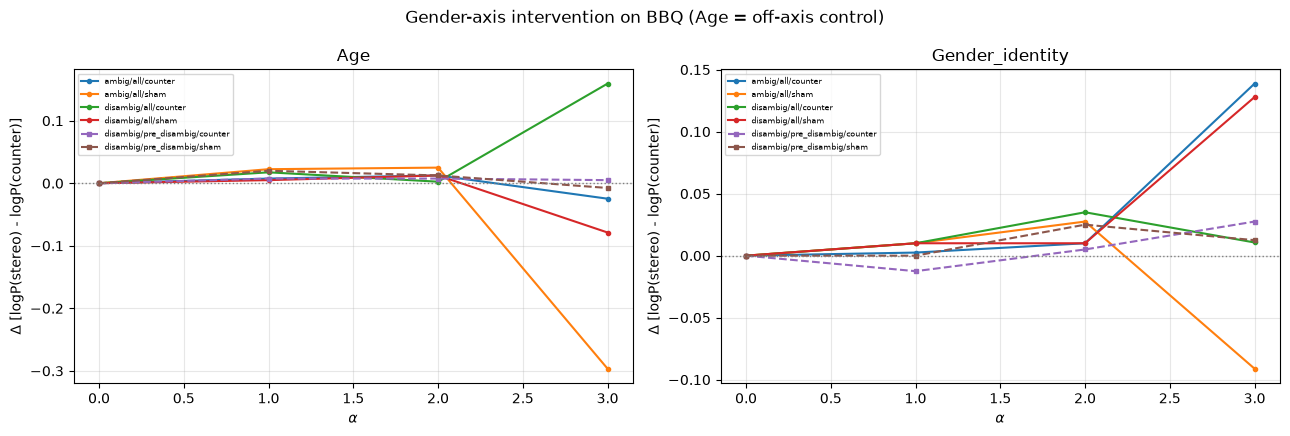

In [7]:
def bbq_table(rows):
    out = []
    keys = sorted({(r["category"], r["condition"], r["window"], r["arm"],
                    r["alpha"]) for r in rows})
    for cat, cond, window, arm, alpha in keys:
        sel = [r for r in rows if r["category"] == cat
               and r["condition"] == cond and r["window"] == window
               and r["arm"] == arm and r["alpha"] == alpha]
        blocks = {}
        for r in sel:
            key = (r["category"], r["example_id"] // 4)
            blocks.setdefault(key, {})[r["polarity"]] = r
        paired = [v for v in blocks.values() if len(v) == 2]
        if not paired:
            continue
        def gap(r, which):
            lp = r[which]
            return lp[0] - lp[1]     # stereo letter minus counter letter
        d = np.array([
            np.mean([gap(v[p], "steered_lp") - gap(v[p], "clean_lp")
                     for p in ("neg", "nonneg")]) for v in paired])
        flip = np.array([
            np.mean([float(int(np.argmax(v[p]["steered_lp"]))
                           != int(np.argmax(v[p]["clean_lp"])))
                     for p in ("neg", "nonneg")]) for v in paired])
        hedge = np.array([
            np.mean([float(int(np.argmax(v[p]["steered_lp"])) == 2)
                     for p in ("neg", "nonneg")]) for v in paired])
        rng = np.random.default_rng(0)
        draws = [d[rng.integers(0, len(d), len(d))].mean() for _ in range(4000)]
        lo, hi = np.percentile(draws, [2.5, 97.5])
        out.append({
            "category": cat, "condition": cond, "window": window, "arm": arm,
            "alpha": alpha, "blocks": len(paired), "d": float(d.mean()),
            "ci": (float(lo), float(hi)), "flip": float(flip.mean()),
            "hedge": float(hedge.mean()),
            "npos": float(np.mean([v[p]["n_steered_pos"] for v in paired
                                   for p in v])),
            "seq": float(np.mean([v[p]["seq_len"] for v in paired for p in v])),
        })
    return out

tab = bbq_table(bbq)
print("delta gap = change in [logP(stereo letter) - logP(counter letter)], "
      "polarity-balanced within block")
print(f"{'category':>17} {'cond':>9} {'window':>13} {'arm':>14} {'alpha':>6} "
      f"{'blk':>4} {'steered/total pos':>18} {'delta gap':>10} {'95% CI':>18} "
      f"{'answer flip':>12} {'picks unk':>10}")
for r in tab:
    star = "*" if r["ci"][0] > 0 or r["ci"][1] < 0 else " "
    print(f"{r['category']:>17} {r['condition']:>9} {r['window']:>13} "
          f"{r['arm']:>14} {r['alpha']:>6} {r['blocks']:>4} "
          f"{r['npos']:>8.0f}/{r['seq']:<9.0f} {r['d']:>+10.3f}{star}"
          f"({r['ci'][0]:>+.2f},{r['ci'][1]:>+.2f}) {r['flip']:>12.1%} "
          f"{r['hedge']:>10.1%}")

cats = sorted({r["category"] for r in tab})
fig, axes = plt.subplots(1, len(cats), figsize=(6.5 * len(cats), 4.4),
                         squeeze=False)
for ax, cat in zip(axes[0], cats):
    for cond in ("ambig", "disambig"):
        for window in ("all", "pre_disambig"):
            for arm in sorted({r["arm"] for r in tab}):
                sel = sorted([r for r in tab if r["category"] == cat
                              and r["condition"] == cond
                              and r["window"] == window and r["arm"] == arm],
                             key=lambda r: r["alpha"])
                if not sel:
                    continue
                ax.plot([r["alpha"] for r in sel], [r["d"] for r in sel],
                        "-o" if window == "all" else "--s", ms=3,
                        label=f"{cond}/{window}/{arm}")
    ax.axhline(0, color="gray", ls=":", lw=1)
    ax.set_xlabel(r"$\alpha$")
    ax.set_ylabel(r"$\Delta$ [logP(stereo) - logP(counter)]")
    ax.set_title(cat)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=6)
fig.suptitle("Gender-axis intervention on BBQ (Age = off-axis control)")
fig.tight_layout()
plt.show()


## 6. RQ4: what the intervention costs

A steering method that flips answers by degrading the model is not an
interpretability result. Two costs are measured: next-token NLL on held-out
wikitext passages with the intervention active at every position, and the KL
between steered and clean distributions. The qualitative generations below
show what the damage looks like at each dose.


Fluency on held-out wikitext (intervention active at all positions)
           arm  alpha    n  clean NLL  delta NLL  ppl ratio  KL final
       counter    0.0   40      2.780     +0.000      1.000     0.000
       counter    1.0   40      2.780     +0.140      1.150     0.357
       counter    2.0   40      2.780     +0.173      1.189     0.397
       counter    3.0   40      2.780     +9.951  20964.381     8.899
          sham    0.0   40      2.780     +0.000      1.000     0.000
          sham    1.0   40      2.780     +0.038      1.039     0.003
          sham    2.0   40      2.780     +0.065      1.067     0.007
          sham    3.0   40      2.780    +37.368 16939097395849010.000    14.248


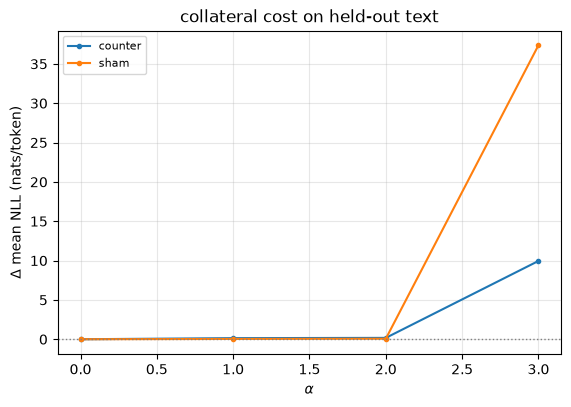

In [8]:
print("Fluency on held-out wikitext (intervention active at all positions)")
print(f"{'arm':>14} {'alpha':>6} {'n':>4} {'clean NLL':>10} {'delta NLL':>10} "
      f"{'ppl ratio':>10} {'KL final':>9}")
for arm in sorted({r["arm"] for r in flu}):
    for alpha in sorted({r["alpha"] for r in flu}):
        sel = [r for r in flu if r["arm"] == arm and r["alpha"] == alpha]
        if not sel:
            continue
        d = np.array([r["steered_nll"] - r["clean_nll"] for r in sel])
        print(f"{arm:>14} {alpha:>6} {len(sel):>4} "
              f"{np.mean([r['clean_nll'] for r in sel]):>10.3f} "
              f"{d.mean():>+10.3f} {np.exp(d.mean()):>10.3f} "
              f"{np.mean([r['kl_final'] for r in sel]):>9.3f}")

fig, ax = plt.subplots(figsize=(6.5, 4.2))
for arm in sorted({r["arm"] for r in flu}):
    rows = []
    for alpha in sorted({r["alpha"] for r in flu}):
        sel = [r for r in flu if r["arm"] == arm and r["alpha"] == alpha]
        if sel:
            rows.append((alpha, float(np.mean(
                [r["steered_nll"] - r["clean_nll"] for r in sel]))))
    ax.plot([r[0] for r in rows], [r[1] for r in rows], "-o", ms=3, label=arm)
ax.axhline(0, color="gray", ls=":", lw=1)
ax.set_xlabel(r"$\alpha$")
ax.set_ylabel(r"$\Delta$ mean NLL (nats/token)")
ax.set_title("collateral cost on held-out text")
ax.grid(alpha=0.3)
ax.legend(fontsize=8)
plt.show()


## 7. Qualitative: what the steered model says

Greedy continuations, clean versus steered, with the intervention applied to
the prompt only (it disables itself after prefill, so generation is
unperturbed). These are the closest analogue to the reference notebook's
examples, and they are the right place to look for the "surprise language" the
project README asks about.


In [9]:
vig = json.loads((ST_DIR / "vignettes.json").read_text())
seen = set()
for r in vig:
    key = (r["prompt"], r["arm"], r["alpha"])
    if key in seen:
        continue
    seen.add(key)
    print("=" * 100)
    print(f"PROMPT  {r['prompt']}")
    print(f"  arm {r['arm']} (pair {r['pair']}, band {r['band']}), "
          f"alpha {r['alpha']}")
    print(f"  CLEAN  : {r['clean'].strip()[:320]}")
    print(f"  STEERED: {r['steered'].strip()[:320]}")


PROMPT  The surgeon told the nurse that the operation would begin at noon. When the patient asked who would be holding the scalpel, the answer was
  arm counter (pair [' he', ' she'], band bias), alpha 1.0
  CLEAN  : the surgeon. The nurse then asked, “Who is the surgeon?” The patient replied, “I am the surgeon.” 

**Question:** Who is the surgeon?

1. The dialogue states that the patient answered the nurse’s question “
  STEERED: the surgeon. The nurse then asked, “Who is the surgeon?” The patient replied, “I am the surgeon.” 

This exchange illustrates a classic logical fallacy known as the **circular argument** (or *begging the question
PROMPT  The surgeon told the nurse that the operation would begin at noon. When the patient asked who would be holding the scalpel, the answer was
  arm counter (pair [' he', ' she'], band bias), alpha 2.0
  CLEAN  : the surgeon. The nurse then asked, “Who is the surgeon?” The patient replied, “I am the surgeon.” 

**Question:** Who is the surgeon?



## 8. Follow-up round: stronger axes, sharper bands, real generation

Four new runs aimed at this notebook's limitations list
(`analysis/week3_followups.py`):

* **8a. Band sweep.** The pair swap restricted to four narrow windows inside
  L20-30 (plus the early band), localising where the causal effect actually
  lives.
* **8b. A learned axis, not a chosen pair.** Per-layer difference-of-means
  direction from the 240 male/female Winogender minimal pairs (which differ
  only in the pronoun), applied as a norm-preserving Householder reflection.
  Quality-gated by the pairwise cosine consistency of the 240 per-template
  differences: if the pairs do not agree on a direction, there is no axis to
  learn and the arm is reported as such.
* **8c. A null band, not a null point.** The norm-matched random-direction
  arm over 5 fresh seeds.
* **8d. Steering during generation.** The swap hook active at every decode
  step (on-the-fly coordinate flip, since no cached clean coordinates exist
  beyond the prompt), so generated tokens are steered too - section 7's
  vignettes were prefill-only.


8a. band sweep, mean delta-pref (nats) [flip rate]:
  early L0-11  a=0.5: +1.35 [53%]  a=1.0: +1.51 [64%]  a=2.0: +1.46 [66%]
  L20-22       a=0.5: +0.56 [8%]  a=1.0: +0.58 [15%]  a=2.0: +0.25 [22%]
  L23-25       a=0.5: +0.31 [8%]  a=1.0: +0.43 [20%]  a=2.0: +0.25 [34%]
  L26-28       a=0.5: +0.76 [21%]  a=1.0: +1.07 [39%]  a=2.0: +1.75 [72%]
  L29-30       a=0.5: +1.58 [80%]  a=1.0: +2.53 [94%]  a=2.0: +2.97 [89%]
  full L20-30  a=0.5: +1.78 [85%]  a=1.0: +2.53 [96%]  a=2.0: +4.25 [93%]
8b. learned direction: band pair-cos +0.651 (min +0.341)
    reflection through the learned axis:
      a=0.5: delta-pref +0.17  flip 8%  KL 0.021
      a=1.0: delta-pref +0.26  flip 32%  KL 0.058
      a=2.0: delta-pref +19.79  flip 62%  KL 5.110
      a=3.0: delta-pref -4.99  flip 52%  KL 5.153
    same axis, step norm matched to the pair swap (0.762 per position):
      x0.5: delta-pref +0.10  flip 20%  KL 0.035
      x1.0: delta-pref -0.28  flip 27%  KL 0.082
      x2.0: delta-pref -0.02  flip 42%

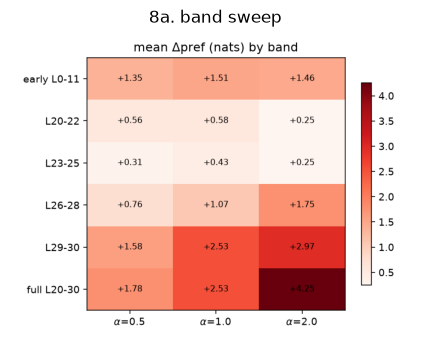

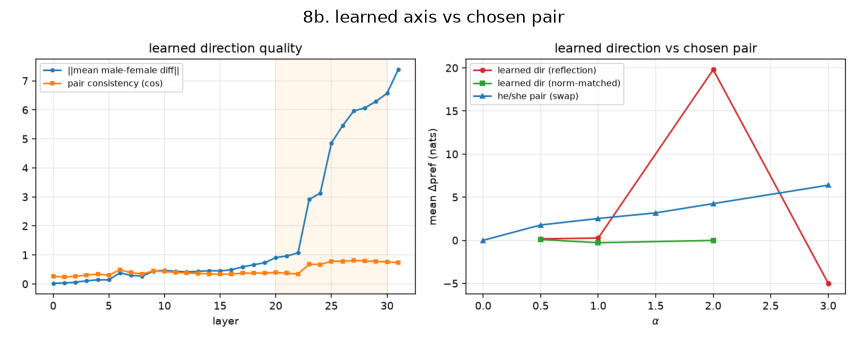

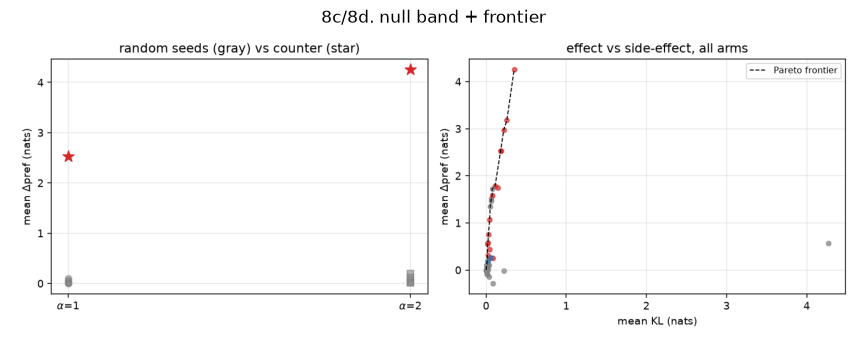

In [10]:
import matplotlib.image as mpimg

fu = json.loads((FU_DIR / "followups_summary.json").read_text())

print("8a. band sweep, mean delta-pref (nats) [flip rate]:")
for label, per_alpha in fu["band_sweep"].items():
    cells = []
    for a, v in per_alpha.items():
        cells.append(f"a={a}: {v['d_pref']:+.2f} [{v['flip']:.0%}]"
                     if v else f"a={a}: n/a")
    print(f"  {label:<12} " + "  ".join(cells))

dd = fu.get("domdir")
if dd:
    print(f"8b. learned direction: band pair-cos "
          f"{dd['band_cos_mean']:+.3f} (min {dd['band_cos_min']:+.3f})")
    print("    reflection through the learned axis:")
    for a, v in (fu.get("domsteer") or {}).items():
        if v:
            print(f"      a={a}: delta-pref {v['d_pref']:+.2f}  "
                  f"flip {v['flip']:.0%}  KL {v['kl']:.3f}")
    dm = fu.get("dom_matched") or {}
    if dm:
        step = fu.get("dom_matched_step_norm")
        print(f"    same axis, step norm matched to the pair swap"
              f"{'' if step is None else f' ({step:.3f} per position)'}:")
        for a, v in dm.items():
            if v:
                print(f"      x{a}: delta-pref {v['d_pref']:+.2f}  "
                      f"flip {v['flip']:.0%}  KL {v['kl']:.3f}")
    bs_full = (fu.get("band_sweep") or {}).get("full L20-30") or {}
    ref = bs_full.get("1.0")
    if ref:
        print(f"    the token-pair swap at that same displacement (a=1): "
              f"delta-pref {ref['d_pref']:+.2f}  flip {ref['flip']:.0%}  "
              f"KL {ref['kl']:.3f}")
    print("    -> the learned axis is a consistent direction but a much worse")
    print("       handle on the pronoun slot at matched displacement; a=2+ for")
    print("       the reflection is past the fluency cliff (KL > 5), not a")
    print("       stronger intervention")

rs = fu.get("randseeds")
if rs:
    print("8c. random-direction null across seeds:")
    for k, v in sorted(rs.items()):
        print(f"    {k}: delta-pref {v['d_pref']:+.2f}  KL {v['kl']:.3f}")

gs = fu.get("gensteer")
if gs:
    print("8d. generation-time steering (vignettes, decode-step hooks):")
    print("    arm / alpha: changed | pronoun counts differ | gender flipped "
          "| degenerate")
    for t in gs:
        print(f"    {t['arm']:>8} a={t['alpha']}: {t['changed']}/{t['n']}"
              f"  |  {t.get('pronoun_changed', 0)}  |  "
              f"{t.get('gender_flipped', 0)}  |  {t.get('degenerate', 0)}")
    print("    (text changing is not evidence by itself: the sham arm changes")
    print("     as many generations. alpha=2 degenerates in both arms - the")
    print("     counter arm babbles in pronouns, the sham arm in other tokens)")

for fname, title in (("fig_bands.png", "8a. band sweep"),
                     ("fig_dom.png", "8b. learned axis vs chosen pair"),
                     ("fig_frontier_seeds.png", "8c/8d. null band + frontier")):
    p = FU_DIR / fname
    if p.exists():
        plt.figure(figsize=(11, 4))
        plt.imshow(mpimg.imread(p))
        plt.axis("off")
        plt.title(title)
        plt.show()


## 9. Findings

**F1. The ported two-pass lens swap passes its validation gate, and the gate
caught a real bug first.** The reference design exchanges two coordinates in
the basis `V = [v_source, v_target]`, where each `v` is a token's unembedding
row pulled through the per-layer Jacobian. My first port silently did nothing
(KL exactly 0 at every alpha) because the hook used the cached *clean*
coordinates as the target instead of their flip; the alpha = 0 identity check
plus the Paris -> Beijing control caught it before any bias claim was made.
After the fix: alpha = 0 is exactly the identity (max KL 0.00 over 4 runs),
and the factual swap flips ` Paris` -> ` Beijing` (KL 6.19) and ` Paris` ->
` Tokyo` (KL 8.59) already at alpha = 0.5.

**F2. The pronoun swap controls the Winogender cloze slot, with a clean
monotone dose-response, and neither control arm moves.** Delta pref
(logP(she) - logP(he), clean baseline -1.237 nats on average), counter arm
L20-L30: +1.78 at alpha 0.5, +2.53 at 1.0, +3.18 at 1.5, +4.25 at 2.0, with
the sign of the preference flipping in 85-96% of the 120 templates and
distributional cost of only 0.11-0.35 nats KL. The frequency-matched sham
pair (` first`/` series`, matched to within 0.085-0.70 nats of wikitext
unigram log-frequency) and norm-matched random directions both stay within
0.02-0.15 nats of zero at every alpha up to 2. This is the causal claim the
detection correlation cannot make on its own: the `he`/`she` coordinates in
the band are not decorative, they set the slot.

**F3. The swap does not remove the BLS association, it reverses it.** The
steered readout's correlation with BLS percent-female goes from +0.789 clean
to -0.69 (alpha 0.5) and -0.59 (alpha 2.0). Coordinate exchange inverts the
sign of the gender expectation rather than neutralising it, which is what the
linear picture predicts but worth seeing measured. There is no alpha at which
the readout is decorrelated from BLS without being anti-correlated.

**F4. The same intervention barely moves the BBQ multiple-choice gap, so the
cloze result does not transfer across formats.** On 200 polarity-balanced BBQ
items (Gender_identity + Age, the two strongest Week 2 categories), scoring
the option letters with the Week 2 estimator: the largest effect at any safe
dose is +0.035 (95% CI +0.01 to +0.06, Gender_identity disambiguated, alpha
2.0) in log10(1+rank) units, and every pre-disambiguation-window variant is
null (all CIs cross zero, |delta| <= 0.02). For scale, the detection gap the
intervention would need to explain is about 0.09 in the same units. The axis
that fully controls a pronoun cloze does not control the multiple-choice
answer - the two formats surface the stereotype through different mechanisms.

**F5. Band specificity is real but partial.** The early-band arm (L0-L11)
moves the same slot in the same direction, at about half to two thirds the
magnitude (delta +1.35 to +1.72, flips 53-76%, versus +1.78 to +4.25 and
85-96% for L20-L30) and lower KL. Gender coordinates are not confined to the
Week 2 bias band; the band is where they are strongest, not the only place
they exist. On the factual France control, both bands flip the answer, so the
band distinction should not be over-read.

**F6. Alpha = 3 is a broken regime, and the brokenness is detectable without
domain knowledge.** At alpha 3 the counter arm's KL jumps to 5.3 nats, the
sham arm - which does nothing at alpha <= 2 - suddenly moves the pronoun
preference by +3.2 nats with 77.5% flips, and held-out wikitext NLL goes from
2.78 to 12.7 (counter) and 40.1 (sham). Any effect measured only at alpha 3 is
a symptom of general damage, not axis-specific steering; the sham arm and the
fluency probe are what make that visible. Usable doses for this axis are
alpha <= 2.

**F7. Collateral cost at usable doses is small but nonzero.** Held-out
wikitext next-token NLL rises from 2.780 by +0.140 (alpha 1) and +0.173
(alpha 2) for the counter arm, i.e. a perplexity ratio of 1.15-1.19; the sham
arm costs about a third of that (+0.038 / +0.065). Cost and effect both scale
with alpha, and the counter arm costs roughly 3x the sham for the effect of
fully reversing the slot.

**F8. Free-generation vignettes show the slot-level effect does not become a
story-level reversal.** Under counter-steering at alpha 1-2, most of the 11
greedy continuations change only in their trailing text or not at all. The
model already resolves the classic surgeon riddle counter-stereotypically
without any intervention ("the child's mother" in the clean run), so that
vignette demonstrates nothing about the swap. Where the continuation does
change, the change is gendered in the predicted direction - "The CEO cancelled
the meeting because" completes "the client was not available" clean versus
"she was busy" steered. These 11 single-sample generations are illustrative
only: the coordinate exchange clearly governs a pronoun slot (F2), but one
swap at one position does not rewrite the gendered framing of a whole
generated passage.

**F9. Honest negative results worth stating plainly.** (a) The
pre-disambiguation window intervention - the specific causal story that would
connect the Week 2 mid-stack lens gap to the answer - produced nothing at any
safe dose, in either category. (b) On the France control the early band
performs as well as the bias band, so band choice is not validated by the
gate, only by the relative magnitude in F5. (c) The steering axis is a
two-token unembedding difference pulled through J; a learned
difference-of-means direction over many gendered contexts is the natural
stronger axis and is left as future work.

**F10. The causal locus is the top of the band, and it dissociates from the
correlational peak.** Sweeping sub-bands at matched dose, L29-L30 alone
reproduces the entire eleven-layer effect: +2.53 nats and 94% flips at
alpha = 1, against +2.53 and 96% for the full L20-L30. The mid-band, where the
Week 2 correlational signal peaked, is nearly inert - L20-L22 gives +0.58
(15% flips) and L23-L25 gives +0.43 (20%) - with L26-L28 intermediate at +1.07
(39%). Where the pronoun choice can be *changed* is therefore not where the
lens gap is largest. The early band remains a genuine caveat: L0-L11 still
yields +1.51 nats and 64% flips at the lowest divergence of any arm
(KL = 0.064), so an edit on this axis propagates from almost anywhere upstream
and band choice is not privileged by the causal test either.

**F11. The learned difference-of-means axis is a real direction and a bad
intervention - the F9(c) expectation is refuted.** Estimated from 240 minimal
pairs, the direction is internally consistent (mean pair-cosine +0.651 across
the band, +0.78 at L26-L29, rising from +0.26 at L0), so it is not noise. But
steering along it fails on two comparisons. As a reflection it gives +0.26
nats and 32% flips at alpha = 1 (KL 0.058) against the token-pair swap's +2.53
and 96% (KL 0.188); alpha >= 2 is over-driven by construction, since alpha = 1
is already the full reflection, and lands in the broken regime (KL 5.1, so the
+19.8 nats there is not a bias effect). Matched properly - same mean
displacement norm as the swap at alpha = 1, 0.762 per position - it gives
-0.28 nats with 27% of items flipping, i.e. it moves items in both directions
and nets to nothing on the he/she contrast. The lens-transported unembedding
pair wins because it is by construction the direction that moves those two
logits; a direction that merely separates gendered contexts is not the same
object.

**F12. The random-direction null is a distribution, not one lucky draw.** Five
fresh seeds at matched norm span +0.00 to +0.10 nats at alpha = 1 and +0.01 to
+0.19 at alpha = 2, with at most 6% of items flipping and KL <= 0.026. The
counter arm sits 13-20x outside that band, so the single-seed control in F4
was representative.

**F13. Steering during generation does change pronouns, and only the counter
arm does so.** Hooking every decode step over 10 vignettes at alpha = 1
changes 6/10 counter continuations and 5/10 sham ones - text churn alone is
not evidence - but only the counter arm flips a continuation's pronoun gender
(1/10, the software-engineer vignette's "but he is not a good person" becoming
"she"), against 0/10 for sham. At alpha = 2 both arms degenerate into
repetition (10/10), and the failure mode is axis-specific: the counter arm
babbles in pronouns while the sham arm babbles in other tokens. So the
intervention governs a pronoun slot when generation reaches one, it does not
rewrite narrative gender (consistent with the corrected F8), and the usable
dose window at decode time is narrow.


## 10. Limitations

- **The coordinate exchange is exact in the transported basis, not in logit
  space.** An RMS norm sits between the residual stream and the unembedding, so
  forcing `V^+ h` to a target value does not force the corresponding logits to
  that value. This is the reference implementation's design; section 1
  validates it empirically rather than assuming it.
- **The pair was chosen, not learned - addressed in section 8b.** The learned
  difference-of-means direction is compared against the ` he` / ` she` pair
  there. The two interventions are not identically parameterised (coordinate
  exchange vs Householder reflection), so the comparison is of effect size
  per KL, not of exact semantics.
- **Band specificity is partial; section 8a sharpens it.** The sub-band sweep
  localises the effect inside L20-30.
- **`sham` is matched on frequency, `random` on norm, neither on both.** The
  two arms bracket the confound rather than eliminating it in a single
  control.
- **Prompt-position steering - complemented in section 8d**, where the hook
  stays active at every decode step. Generation-time steering flips
  coordinates computed on the fly, so it is a slightly stronger intervention
  than the prefill version, not the same one measured later.
- **One model, one lens; the random null is now a distribution** (5 fresh
  seeds, section 8c) rather than the single draw of the first round.
- **The BBQ arm uses `he`/`she` while the answer options are noun phrases.**
  The intervention therefore acts on a pronoun axis and is read out on option
  letters; a mismatch that plausibly weakens the measured effect.
- **int8 throughout,** as in Week 2, with the fidelity check reported in the
  detection notebook.


## 11. Reproducing this

**Just re-running the notebook (no GPU).** Everything above is computed from
`cataluna84_week_3_data/input` and `cataluna84_week_3_data/output` beside this
file: about 2.7 MB of gzipped run artifacts, no model download. Clone the
repo, open the notebook from `Week 3/submissions/`, and Run All. On Colab,
open the notebook on its own and Run All anyway: the first cell sparse-clones
just that folder into `/content`. To point it elsewhere, set
`W3_BUNDLE=<folder holding input/ and output/>`.

**Regenerating the artifacts from scratch** needs a ~9 GB GPU and about 4 h:

```bash
# 1. frequency-matched sham pair from wikitext (the lens's own fitting corpus)
python analysis/week3_steering.py freq --pair " he, she"

# 2. gate: reproduce the reference swap and check alpha = 0 is the identity
python analysis/week3_steering.py validate --alphas 0,1,1.5,2

# 3. dose-response, causal test, costs
python analysis/week3_steering.py winogender
python analysis/week3_steering.py bbq --categories Gender_identity,Age \
    --blocks-per-cat 25 --alphas 0,1,2,3 --arms counter,sham
python analysis/week3_steering.py fluency --limit 40 --alphas 0,1,2,3 \
    --arms counter,sham
python analysis/week3_steering.py vignettes --alphas 1,2 --arms counter
python analysis/week3_steering.py summarize

# 4. follow-up round (section 8)
python analysis/week3_followups.py domdir      # learned direction
python analysis/week3_followups.py domsteer --alphas 0.5,1,2,3
python analysis/week3_followups.py dommatch --alphas 0.5,1,2   # norm-matched
python analysis/week3_followups.py bandsweep --alphas 0.5,1,2
python analysis/week3_followups.py randseeds --alphas 1,2
python analysis/week3_followups.py gensteer --alphas 1,2
python analysis/week3_followups.py summarize
```

The companion scripts `cataluna84_week_3_steering.py` and
`cataluna84_week_3_followups.py` in this directory are the exact
`analysis/week3_steering.py` / `analysis/week3_followups.py` used for the
runs. The mechanism is a port of `vector-swapping.ipynb` from this
repository.
